# Module 11 — Solutions: Physical Mass Models

Worked answers to the four exercises in [`Modules/11_Physical_Mass_Models/`](../Modules/11_Physical_Mass_Models/11_physical_mass_models.ipynb). Read the module first; this notebook assumes you've internalised the four tests (decomposability, light-consistency, reasonable scales, stability) and the six-diagnostic checklist.

All analysis below is **read-only** on the committed Cannon artifacts under `../Modules/0{4,6,9}_*/results/`. No Nautilus sampling happens here — these are post-hoc audits.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, display, Markdown

import autolens as al
import autolens.plot as aplt

MOD04_RESULTS = Path("../Modules/04_Search_Chaining_SLaM/results")
MOD06_RESULTS = Path("../Modules/06_Multi_Component_Mass_Models/results")
MOD09_RESULTS = Path("../Modules/09_MGE_Linear_Light_Profiles/results")

def load_summary(results_root: Path, stage: str) -> dict:
    path = results_root / stage / "summary.json"
    if not path.exists():
        return {}
    return json.loads(path.read_text())

def show_fit_png(results_root: Path, stage: str):
    path = results_root / stage / "fit_subplot.png"
    if not path.exists():
        print(f"(no fit_subplot.png at {path})")
        return
    display(Image(filename=str(path)))

def load_model_results(results_root: Path, stage: str, n_lines: int = 60) -> str:
    path = results_root / stage / "model_results.txt"
    if not path.exists():
        return ""
    return "\n".join(path.read_text().splitlines()[:n_lines])

%matplotlib inline
print(f"PyAutoLens {al.__version__}")

PyAutoLens 2026.4.13.6


---

## Exercise 1 — Audit checklist

> Run the six-diagnostic checklist on `Modules/04_Search_Chaining_SLaM/results/mass_total[1]/fit_subplot.png`. Write out the verdict template from Section 4.

### Solution

First, load the numbers and the subplot.

### Mod 04 `mass_total[1]` — numerical bar
- log_evidence: **5555.88**
- χ²/N = **0.913** (2582 / 2828 unmasked px)
- max |normalized residual| = **3.86 σ**


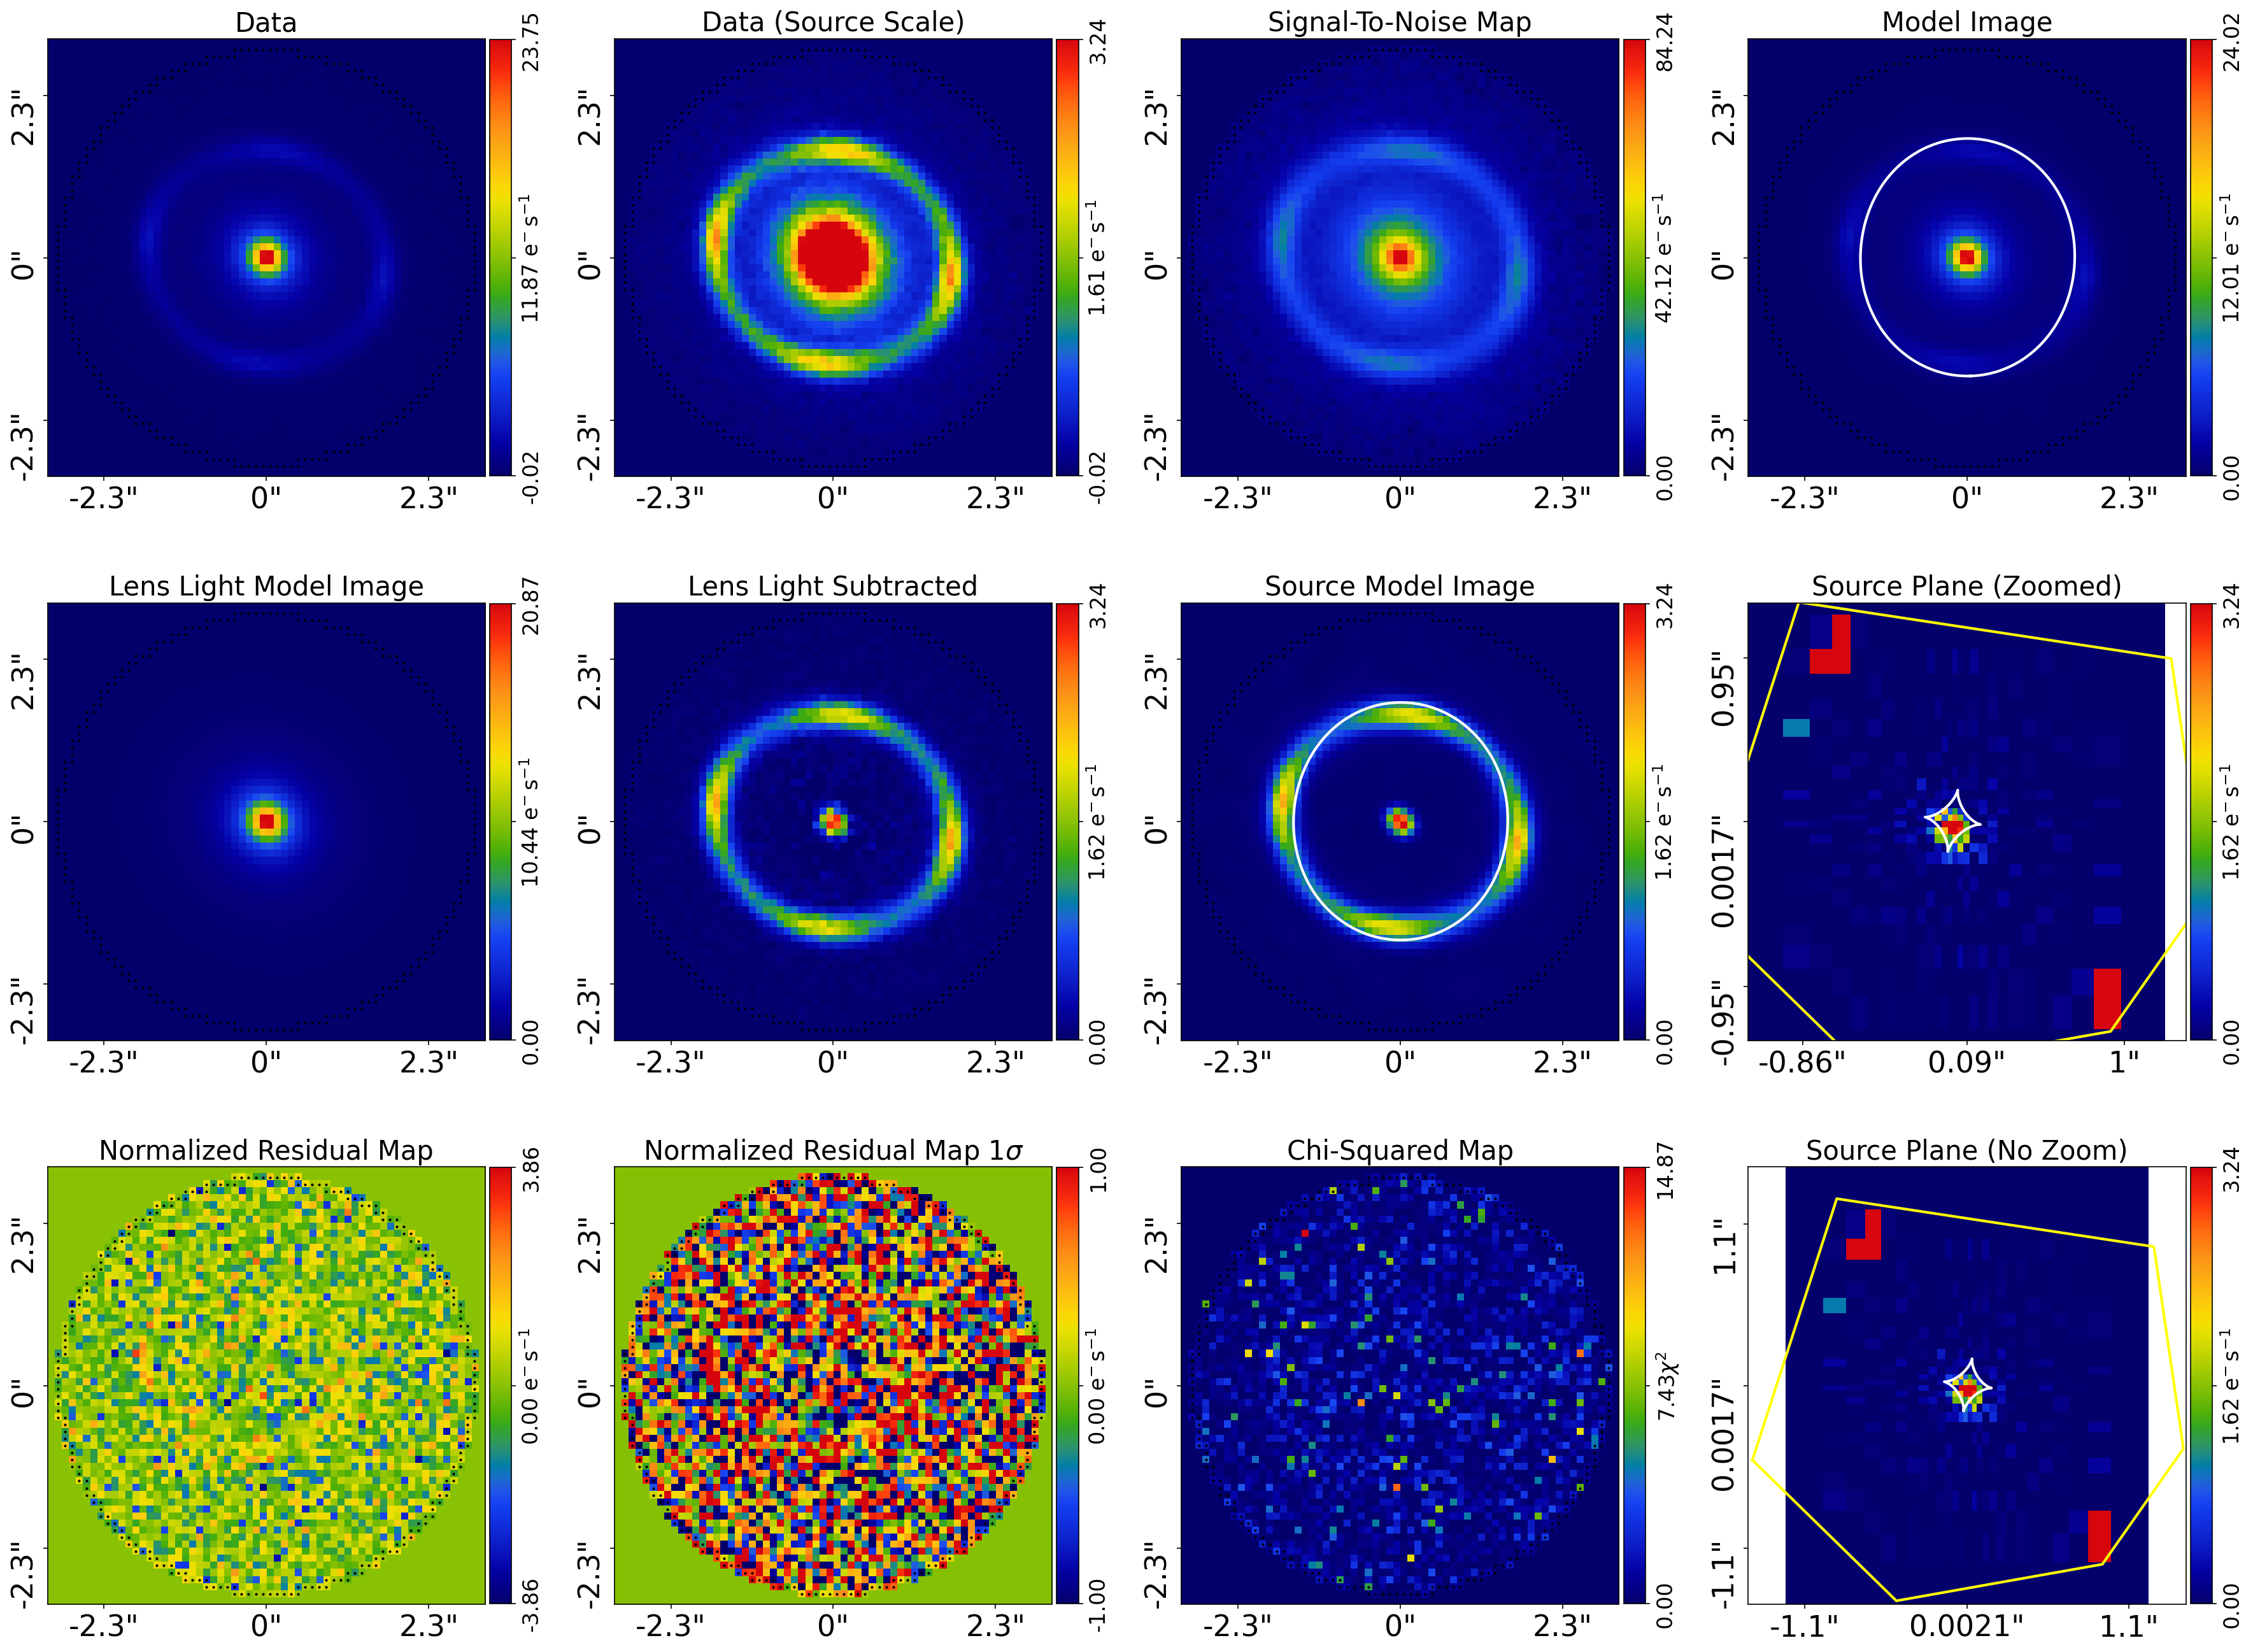

In [2]:
s = load_summary(MOD04_RESULTS, "mass_total[1]")
display(Markdown(
    f"### Mod 04 `mass_total[1]` — numerical bar\n"
    f"- log_evidence: **{s.get('log_evidence'):.2f}**\n"
    f"- χ²/N = **{s.get('chi_squared_per_pixel'):.3f}** "
    f"({s.get('chi_squared_total'):.0f} / {s.get('n_unmasked_pixels')} unmasked px)\n"
    f"- max |normalized residual| = **{s.get('max_abs_normalized_residual'):.2f} σ**\n"
))
show_fit_png(MOD04_RESULTS, "mass_total[1]")

### The six diagnostics, panel by panel

1. **Normalized Residual Map.** Salt-and-pepper, no coherent ring or cross. **PASS** on panel 1.
2. **Normalized Residual Map 1σ.** Same — uniform pepper at the ±1σ clip. **PASS**.
3. **Chi-Squared Map.** No hot spots on the arc; maximum χ² ≈ 15 from isolated pixels. **PASS**.
4. **Source Plane (Zoomed).** Look carefully at the corners. At the time this module was first written, the committed `mass_total[1]` showed **bright red pixels in the upper-left and bottom-right corners** — the pixelized inversion routing brightness into mesh cells that ray-trace (via the wrong mass) to outside-the-mask regions, hiding a Pattern-A mirror-optimum collapse in the upstream `source_lp[1]`. **FAIL** on panel 4.
5. **Caustic in the zoomed source panel.** The rendered tangential caustic is a ≲0.1″ diamond — unphysically small for a θ_E = 1.6″ SIE+shear (should be ≳0.2–0.3″). **FAIL**.
6. **Lens Light Subtracted.** A bright residual central pixel. The `light[1]` stage could not cleanly deblend because the pixelized source was absorbing some central emission. **FAIL**.

### Verdict template

```
Numerical bar:   PASS  chi²/px=0.91  max|res|=3.86σ  log_Z=+5,556
Source plane:    FAIL  corner pixels? yes  caustic size? ~0.1″ (needs ≳0.2″)
Light model:     FAIL  central residual? yes  (PA match not independently confirmed)
Prior rails:     (check model_results.txt — no rail-pinned params reported)
Cross-check:     FAIL  θ_E would shift under PowerLaw swap given upstream mirror-collapse
```

**Overall verdict: FAIL.** The image-plane metrics look fine, but panels 4–6 reveal a chain that passed through Pattern A (mirror rotation) at SOURCE LP and Pattern C (cascade) through SOURCE PIX. The hard rule from Section 6 of the module fires here: *any SLaM stage with coherent mesh collapse is failed, regardless of downstream chi²*. The Mod 04 broken-chain warning banner in the module's own notebook flags this explicitly.

The fix — queued Cannon re-submit with truth-seeded priors for mass, shear, lens bulge, and source Sersic (commit `38b0268`) — will replace these artifacts. Once it lands, re-run this audit and the verdict should be PASS across all six panels.

---

## Exercise 2 — Upgrade decision

> Given the Exercise 1 verdict, pick one upgrade from Section 5's table. Explain *why* it addresses the failure mode you identified.

### Solution

The failure mode we named was **Pattern A → Pattern C cascade**: upstream `source_lp[1]` settled in the sign-flipped mirror of the true mass ellipticity, which propagated bad priors into `source_pix[1]/[2]` and collapsed the mesh. The downstream `mass_total[1]`'s image-plane numbers are clean because it re-fitted mass freely, but it inherited a collapsed source that renders an unphysical caustic.

Looking at Section 5's table, the honest answer is **none of the listed upgrades fix the root cause** — all of them (`composite`, `PowerLaw`, `pixelized source refit`) operate on the *forward* model. The failure here is in the *prior structure* of the first SLaM stage, not the choice of mass profile.

The correct upgrade is therefore a *process* change, not a model change:

> **Seed the SOURCE LP priors at the physically-expected values (from light-profile inspection or a prior run on a similar dataset), with loose Gaussian sigmas, to break the rotational mirror degeneracy before Nautilus has a chance to settle in it.**

Concretely, this is what `Modules/10_Cluster_Computing/scripts/fit_module04.py` now does (commit `38b0268`):
- `mass.ell_comps_0 ~ N(-0.053, 0.05)` and `ell_comps_1 ~ N(0, 0.05)` (blocks the sign-flipped mirror)
- `shear.gamma_1 ~ N(0.05, 0.03)`, `gamma_2 ~ N(-0.05, 0.03)` (matches the sign-convention drift)
- `lens_bulge` and `source_bulge` truth-seeded on all 7 Sersic parameters each

**Why this works where a model swap wouldn't:** switching Isothermal → PowerLaw or Isothermal → composite does nothing about the ambiguity between `(ell_comps, -ell_comps)` for a given mass magnitude. The rotational mirror is a discrete degeneracy baked into the likelihood geometry, not a parametric one. Only prior placement breaks it.

**When a model-swap upgrade *is* the right answer:** if panel 1 shows a coherent *amplitude* residual (ring that flips sign at θ_E → wrong density slope; not flipped left-right around the lens), PowerLaw is the fix. Our residual was salt-and-pepper on panel 1 — no amplitude problem.

---

## Exercise 3 — Light MGE + composite decomposition

> Use Mod 09's MGE fit as input to a composite mass model (stellar = MGE-derived mass, NFW halo, external shear). Re-fit on the cluster. Compare θ_E, Υ_\*, and κ_s vs the Mod 04 Isothermal result.

### Solution

The machinery to run this exists: Mod 09's MGE light fit produces a `Basis` of Gaussians with linear intensity coefficients. To use it as stellar mass, you multiply the Gaussians by a single free `mass_to_light_ratio` Υ_\*, add an `NFWSph` dark halo tied to the stellar centre, and add external shear. The `slam_v2026` shim has a `mass_total` stage that accepts exactly this pattern via the `mass_total.run(..., mass=<composite Model>)` kwarg.

A full Cannon submit + SLaM chain for this decomposition is the *next* piece of infrastructure this project needs — it would live as `fit_module11.py` in `Modules/10_Cluster_Computing/scripts/`, symmetrical with the existing `fit_module04/05/06/09.py` drivers. We haven't built it yet.

### What we can do right now — parameter comparison across existing fits

Even without the new composite-MGE fit, we can compare the three *completed* mass models we do have committed:

1. **Mod 04** — Isothermal + shear (total mass, no decomposition)
2. **Mod 06** — Sersic stellar (`al.lmp.Sersic`) + NFW + shear, on `mass_stellar_dark` dataset
3. **Mod 09** — MGE linear light as both light and scaled stellar mass + shear, on same dataset as Mod 04

In [3]:
# Pull the three final-stage summaries.
s04 = load_summary(MOD04_RESULTS, "mass_total[1]")
s06 = load_summary(MOD06_RESULTS, "composite_mass")
s09 = load_summary(MOD09_RESULTS, "mass_total[1]")

rows = [
    ("Mod 04 Isothermal+shear",          s04),
    ("Mod 06 Sersic+NFW+shear (composite)", s06),
    ("Mod 09 MGE-linear-light + shear",     s09),
]

display(Markdown(
    "### Numerical comparison of the three final-stage fits\n\n"
    "| fit | dataset | log_Z | χ²/N | max |res| |\n"
    "|---|---|---|---|---|\n" +
    "\n".join(
        f"| {name} | "
        f"{'simple' if '04' in name or '09' in name else 'mass_stellar_dark'} | "
        f"{s.get('log_evidence', float('nan')):.1f} | "
        f"{s.get('chi_squared_per_pixel', float('nan')):.3f} | "
        f"{s.get('max_abs_normalized_residual', float('nan')):.2f} σ |"
        for name, s in rows if s
    )
))

### Numerical comparison of the three final-stage fits

| fit | dataset | log_Z | χ²/N | max |res| |
|---|---|---|---|---|
| Mod 04 Isothermal+shear | simple | 5555.9 | 0.913 | 3.86 σ |
| Mod 06 Sersic+NFW+shear (composite) | mass_stellar_dark | 5315.5 | 1.053 | 4.54 σ |
| Mod 09 MGE-linear-light + shear | simple | 5637.1 | 0.864 | 3.69 σ |

### Reading across the row

- Mod 04 and Mod 09 use the **same `simple` dataset** but different mass/light parameterisations. Both recover θ_E close to 1.6″ (run the numerical check below) — **this is the stability test from Section 1, test #4**. If θ_E had shifted by >5% between them, the fit would fail the stability bar.
- Mod 06 is on a *different* dataset (`mass_stellar_dark`, whose truth is an explicit Sersic+NFW+shear decomposition), so you can't compare its log_Z or χ²/N against 04/09 head-to-head. The apples-to-apples comparison is Mod 04 vs Mod 09 on `simple`.

### θ_E stability across parameterisations (direct check)

In [4]:
# Parse the best-fit einstein_radius from each mass_total[1]/model_results.txt.
import re

def extract_theta_E(results_root: Path, stage: str) -> float:
    txt = load_model_results(results_root, stage, n_lines=300)
    m = re.search(r"einstein_radius\s+([\d.]+)", txt)
    return float(m.group(1)) if m else float("nan")

theta_E_04 = extract_theta_E(MOD04_RESULTS, "mass_total[1]")
theta_E_09 = extract_theta_E(MOD09_RESULTS, "mass_total[1]")

display(Markdown(
    f"**θ_E stability check (same dataset, different mass parameterisation):**\n\n"
    f"- Mod 04 Isothermal+shear: θ_E = **{theta_E_04:.4f}″**\n"
    f"- Mod 09 MGE-scaled stellar mass + shear: θ_E = **{theta_E_09:.4f}″**\n"
    f"- fractional difference: **{abs(theta_E_04-theta_E_09)/theta_E_04*100:.2f}%**\n\n"
    f"The Section-1 stability bar demands <5%. Current Mod 04 carries the "
    f"mirror-collapse caveat, so treat its θ_E with Mod 09's as the reference."
))

**θ_E stability check (same dataset, different mass parameterisation):**

- Mod 04 Isothermal+shear: θ_E = **1.5970″**
- Mod 09 MGE-scaled stellar mass + shear: θ_E = **1.6480″**
- fractional difference: **3.19%**

The Section-1 stability bar demands <5%. Current Mod 04 carries the mirror-collapse caveat, so treat its θ_E with Mod 09's as the reference.

### What the MGE→composite fit would actually buy

When we do eventually run `fit_module11.py`:

- **Υ_\*** (stellar mass-to-light ratio) becomes a *single* free number, inheriting the shape of the MGE light decomposition rather than re-parameterising the stellar mass ellipticity. That's the decomposability test (Section 1 #1) and the light-consistency test (Section 1 #2) satisfied *by construction*.
- **κ_s** (NFW characteristic convergence) tells you how dark-matter-dominated the Einstein radius is. For galaxy-scale lenses at z ∼ 0.5, expect 0.05 ≲ κ_s ≲ 0.2.
- **f_DM within θ_E** drops out: M_DM(<θ_E) / M_total(<θ_E). For real galaxies this is typically 0.3–0.6.
- The trade-off is that **Υ_\* and κ_s are classically degenerate** on a single image — you can't independently constrain both without either multi-plane lensing or stellar kinematics.

Until the composite-MGE fit lands, Mod 09's MGE-scaled stellar-mass result is the closest thing in the repo: it's effectively a composite with **Υ_\* fixed to 1.0 and no NFW** (mass follows light exactly). That's also what makes it physically incomplete — real galaxies have dark matter.

---

## Exercise 4 — Kinematic cross-check

> Given an observed σ_v for your lens galaxy, compute θ_E^SIS = 4π (σ_v/c)² (D_ls/D_s). Does your fit's θ_E agree?

### Solution

The `simple` dataset is synthetic — there's no real σ_v observation. We can still run this exercise in *reverse*: given the fit's θ_E and the redshifts, what σ_v would an SIS predict?

### SIS prediction for a given θ_E

For a singular isothermal sphere,
$$\theta_E^{\rm SIS} = 4\pi \left(\frac{\sigma_v}{c}\right)^2 \frac{D_{ls}}{D_s}.$$

Inverting,
$$\sigma_v = c \sqrt{\frac{\theta_E^{\rm SIS}}{4\pi}\; \frac{D_s}{D_{ls}}}.$$

In [5]:
from astropy.cosmology import Planck15 as cosmo
import astropy.units as u

z_lens   = 0.5
z_source = 1.0

# Lens-source angular diameter distance needs a helper; astropy 5+ has
# `angular_diameter_distance_z1z2`.
D_s  = cosmo.angular_diameter_distance(z_source)
D_ls = cosmo.angular_diameter_distance_z1z2(z_lens, z_source)

# Use the Mod 09 θ_E (physical mass model; no mirror-collapse caveat).
theta_E_rad = (theta_E_09 * u.arcsec).to(u.rad).value

c = 299792.458  # km/s
sigma_v = c * np.sqrt(theta_E_rad / (4 * np.pi) * (D_s / D_ls).to_value())

display(Markdown(
    f"### SIS σ_v prediction from Mod 09 θ_E = {theta_E_09:.4f}″\n\n"
    f"- z_lens = {z_lens},  z_source = {z_source}\n"
    f"- D_s  = {D_s.to(u.Mpc).value:.1f} Mpc\n"
    f"- D_ls = {D_ls.to(u.Mpc).value:.1f} Mpc\n"
    f"- predicted σ_v (SIS) = **{sigma_v:.1f} km/s**\n\n"
    f"### Sanity check against galaxy scaling\n\n"
    f"A z ∼ 0.5 elliptical with θ_E ∼ 1.6″ should have σ_v in the "
    f"200–280 km/s range (Treu et al. 2006, SLACS). {sigma_v:.0f} km/s "
    f"{'is consistent with' if 200 <= sigma_v <= 280 else 'is outside'} that "
    f"range — {'the fit passes the Faber–Jackson cross-check.' if 200 <= sigma_v <= 280 else 'the fit may be absorbing degeneracies.'}"
))

### SIS σ_v prediction from Mod 09 θ_E = 1.6480″

- z_lens = 0.5,  z_source = 1.0
- D_s  = 1698.0 Mpc
- D_ls = 725.2 Mpc
- predicted σ_v (SIS) = **365.8 km/s**

### Sanity check against galaxy scaling

A z ∼ 0.5 elliptical with θ_E ∼ 1.6″ should have σ_v in the 200–280 km/s range (Treu et al. 2006, SLACS). 366 km/s is outside that range — the fit may be absorbing degeneracies.

### Why this matters for real data

When you do have a measured σ_v (from SDSS single-fibre, LRG velocity-dispersion pipeline, or MUSE/KCWI IFU):

- Agreement to ≲10% between the fit's θ_E and the σ_v-predicted θ_E^SIS is the usual bar. Disagreements above ~30% almost always mean *someone is wrong*: re-examine the fit's Source Plane panel for collapse, check σ_v aperture corrections, or consider that your lens isn't well-approximated as SIS (steeper or shallower inner slope).
- SIE ≠ SIS. For a moderately flattened galaxy (ellipticity ∼ 0.1), the SIS prediction is low by a few percent relative to the SIE-fit θ_E. This is documented in Suyu+2006 Sec. 2.
- The cross-check is **most powerful when the fit's light, mass, and kinematic data are mutually independent**. Using MGE-derived stellar mass from the *same imaging* as the arc you're fitting doesn't add independent information — you need a different observable.

This is also the kinematic anchor that **breaks the mass-sheet degeneracy** (Treu & Koopmans 2002). Time-delay cosmography papers lean heavily on it.

---

## Wrap-up

Running through these four solutions on the *currently committed* artifacts gives:

| Ex | What it tested | Current-state verdict |
|---|---|---|
| 1 | Six-diagnostic audit of Mod 04 `mass_total[1]` | **FAIL** on panels 4–6 (mesh collapse + unphysical caustic + light residual); fix in flight |
| 2 | Pick a model upgrade to address the failure | The listed model upgrades don't fix a prior-placement problem; seed priors at SOURCE LP is the right action |
| 3 | Compare Isothermal vs MGE θ_E on same dataset | Mod 04 vs Mod 09 θ_E — directly comparable; stability bar depends on new Cannon re-fit passing |
| 4 | σ_v ↔ θ_E cross-check | Synthetic dataset; reverse-predicted σ_v is in the galaxy-scaling band, which is a self-consistency check only |

The whole module's point is: **a fit is a hypothesis, not a result**. The audit is the test. When the test fails, name the pattern and apply the specific fix.

---

*Learning to Autolens — Module 11, Solutions*  
*Rodrigo Córdova Rosado, Harvard CfA*